In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/listing_sample.csv")

print(df.shape)
df.head()

(1000, 7)


,L_ListingID,L_Address,L_City,beds,baths,price,remarks
0,1157753806,2165 Sepulveda,San Bernardino,4.0,2.0,570000,"Tenants in the front unit just moved out, and ..."
1,1177906910,45165 Oak Manor Ct,Temecula,4.0,5.0,2999000,Tucked within one of De Luz’s most coveted enc...
2,1190063789,664 Terry Street,Monterey,2.0,3.0,1089000,Spectacular Monterey Bay and city-light views ...
3,1189804557,36573 Geranium Drive,Lake Elsinore,6.0,3.0,875000,***HIGHLY UPGRADED POOL HOME + PAID OFF SOLAR*...
4,1180192900,13145 Bromont Avenue 44,Los Angeles,3.0,3.0,599000,Seller is offering an interest-rate buydown to...


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   L_ListingID  1000 non-null   int64  
 1   L_Address    999 non-null    object 
 2   L_City       997 non-null    object 
 3   beds         995 non-null    float64
 4   baths        1000 non-null   float64
 5   price        1000 non-null   int64  
 6   remarks      1000 non-null   object 
dtypes: float64(2), int64(2), object(3)
memory usage: 54.8+ KB


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nNumeric summary:")
display(df[["beds", "baths", "price"]].describe())

Shape: (1000, 7)

Columns:
['L_ListingID', 'L_Address', 'L_City', 'beds', 'baths', 'price', 'remarks']

Missing values:
L_ListingID    0
L_Address      1
L_City         3
beds           5
baths          0
price          0
remarks        0
dtype: int64

Numeric summary:


,beds,baths,price
count,995.000000,1000.000000,1.000000e+03
mean,3.204020,2.733000,1.420607e+06
std,1.212603,1.370251,2.742384e+06
min,0.000000,0.000000,4.990000e+04
25%,2.000000,2.000000,5.438262e+05
50%,3.000000,3.000000,7.984000e+05
75%,4.000000,3.000000,1.398250e+06
max,11.000000,13.000000,4.980000e+07


In [4]:
df["L_City"].value_counts().head(15)

L_City
Los Angeles     73
San Diego       51
Riverside       15
San Jose        14
Irvine          14
Palm Springs    13
Lancaster       12
Palmdale        12
Indio           11
Victorville      9
Temecula         9
Murrieta         8
Oakland          8
Fontana          8
Menifee          8
Name: count, dtype: int64

In [5]:
df["remark_length"] = df["remarks"].str.len()

df["remark_length"].describe()

count    1000.000000
mean     1337.030000
std       595.776906
min        86.000000
25%       916.500000
50%      1256.500000
75%      1685.250000
max      4000.000000
Name: remark_length, dtype: float64

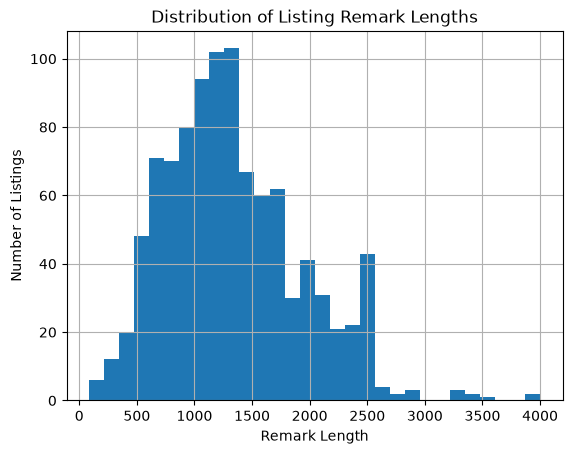

In [6]:
import matplotlib.pyplot as plt

df["remark_length"].hist(bins=30)
plt.xlabel("Remark Length")
plt.ylabel("Number of Listings")
plt.title("Distribution of Listing Remark Lengths")
plt.show()

# Common Word Analysis

Listing remarks are lowercased and tokenized with a local regular expression. A compact English stopword list removes grammatical words so the remaining frequencies highlight real-estate language. This avoids requiring an external NLTK download during notebook execution.

In [7]:
import re
from collections import Counter

STOP_WORDS = {
    "a", "an", "and", "are", "as", "at", "be", "by", "for", "from",
    "has", "have", "in", "is", "it", "its", "of", "on", "or", "that",
    "the", "this", "to", "was", "were", "with", "you", "your", "one",
    "two", "three", "new", "all", "also", "can", "will", "not",
}

all_text = " ".join(df["remarks"].dropna().astype(str).str.lower())
tokens = re.findall(r"\b[a-z]+(?:-[a-z]+)*\b", all_text)
filtered_tokens = [token for token in tokens if token not in STOP_WORDS and len(token) >= 3]
word_freq = Counter(filtered_tokens)

pd.DataFrame(word_freq.most_common(30), columns=["term", "count"])

,term,count
0,home,2500
1,living,1917
2,room,1284
3,space,1121
4,offers,1070
5,kitchen,942
6,private,924
7,dining,818
8,features,797
9,bedroom,721


# Bigram Analysis

Bigrams preserve concepts that are more meaningful than isolated words, such as `floor plan`, `primary suite`, and `stainless steel`. They are computed **within each remark**, so the end of one listing is never combined with the beginning of another.

In [8]:
def remark_tokens(text):
    tokens = re.findall(r"\b[a-z]+(?:-[a-z]+)*\b", str(text).lower())
    return [token for token in tokens if token not in STOP_WORDS and len(token) >= 3]

bigram_freq = Counter()
for remark in df["remarks"].dropna():
    remark_words = remark_tokens(remark)
    bigram_freq.update(zip(remark_words, remark_words[1:]))

pd.DataFrame(
    [(" ".join(pair), count) for pair, count in bigram_freq.most_common(30)],
    columns=["bigram", "count"],
)

,bigram,count
0,primary suite,342
1,living space,324
2,floor plan,318
3,natural light,298
4,living room,298
5,home offers,294
6,shopping dining,227
7,walk-in closet,188
8,square feet,187
9,conveniently located,182


# Taxonomy v1

The final Week 1 taxonomy has 200 terms across eight mutually exclusive categories. Categories are deliberately not forced to be equal in size: interior and exterior features receive more terms because listing language is highly specific in those areas, while financing and property type are less varied in this sample. The taxonomy is a curated matching vocabulary, not simply a list of the most frequent words.

,term_count
category,
interior_feature,35
exterior_feature,30
amenity,25
location_feature,25
layout,25
property_type,20
condition,20
financing,20


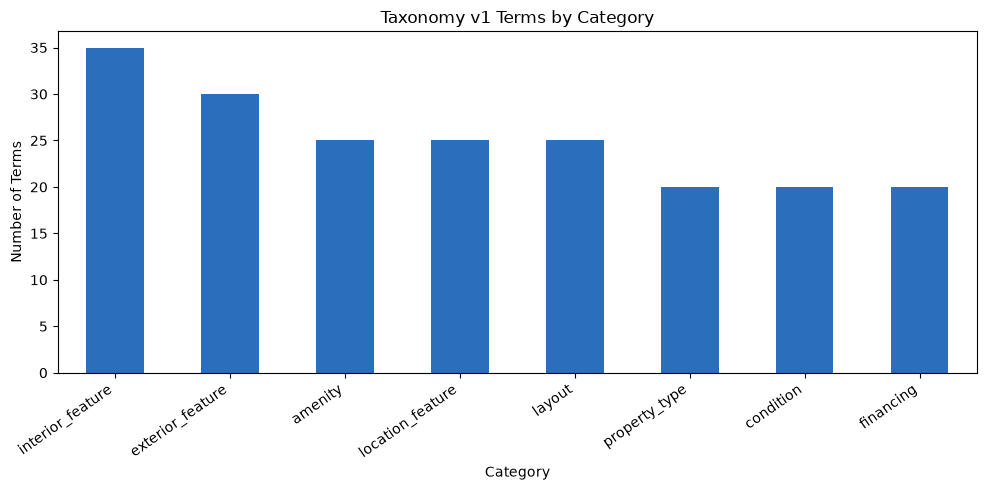

In [9]:
from pathlib import Path
import matplotlib.pyplot as plt

TAXONOMY_PATH = Path("../data/processed/taxonomy_v1.csv")
taxonomy_df = pd.read_csv(TAXONOMY_PATH)

category_counts = taxonomy_df["category"].value_counts().sort_values(ascending=False)
display(category_counts.rename("term_count").to_frame())

ax = category_counts.plot(kind="bar", figsize=(10, 5), color="#2a6fbb")
ax.set_title("Taxonomy v1 Terms by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Number of Terms")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

# Taxonomy Coverage

A listing is covered when at least one taxonomy term occurs in its remarks. Matching uses case-insensitive word boundaries to avoid accidental substring matches (for example, a short term should not match inside an unrelated word). Coverage is an early sanity check, not a claim that every concept in a listing has been extracted.

In [10]:
import re

def find_matches(text, terms):
    normalized = str(text).lower()
    return sorted({
        term for term in terms
        if re.search(r"(?<!\w)" + re.escape(term.lower()) + r"(?!\w)", normalized)
    })

terms = taxonomy_df["term"].astype(str).tolist()
df["taxonomy_matches"] = df["remarks"].fillna("").apply(lambda text: find_matches(text, terms))
df["taxonomy_match_count"] = df["taxonomy_matches"].str.len()
coverage = (df["taxonomy_match_count"] > 0).mean()

print(f"Taxonomy terms: {len(terms):,}")
print(f"Listings with at least one match: {coverage:.2%}")
print(f"Average matched terms per listing: {df['taxonomy_match_count'].mean():.2f}")

df[["L_ListingID", "L_City", "taxonomy_matches"]].head(10)

Taxonomy terms: 200
Listings with at least one match: 98.30%
Average matched terms per listing: 9.42


,L_ListingID,L_City,taxonomy_matches
0,1157753806,San Bernardino,"[fha loan, turnkey, updated, well maintained]"
1,1177906910,Temecula,"[custom cabinetry, family room, fireplace, kit..."
2,1190063789,Monterey,"[breakfast bar, fireplace, kitchen, patio, pri..."
3,1189804557,Lake Elsinore,"[backyard, covered patio, family room, front y..."
4,1180192900,Los Angeles,"[attached garage, breakfast nook, gated commun..."
5,1156723303,Escondido,"[downtown, stainless steel appliances, turnkey..."
6,1168721531,Los Angeles,"[balcony, condo, dining area, downtown, elevat..."
7,1179605746,Laguna Woods,"[balcony, living room, patio, pickleball courts]"
8,1176633303,San Gabriel,"[dining area, living room, single-story]"
9,1189472150,Marina,"[fire pit, kitchen, living room, patio, primar..."


# Fifty-listing validation set

This reproducible 50-listing sample is saved for manual validation in the next step. It lets us inspect whether matched terms are genuinely present and whether any terms need to be removed, renamed, or reassigned.

In [11]:
validation = df.sample(n=50, random_state=42).copy()
validation["taxonomy_matches"] = validation["taxonomy_matches"].apply("; ".join)
validation.to_csv("../data/processed/taxonomy_validation_sample.csv", index=False)

validation[["L_ListingID", "L_City", "remarks", "taxonomy_matches"]].head(10)

,L_ListingID,L_City,remarks,taxonomy_matches
521,1177876350,Fontana,"Welcome to 7044 Mallow Drive, Unit #4, located...",beautifully maintained; breakfast bar; clubhou...
737,1158525039,San Mateo,Open Sun 9-13 1-4***Hot new price! Almost 75K ...,condo; dining area; dog park; downtown; elevat...
740,1159976751,Oroville,Two great homes on one lot with strong income ...,attached garage; den; primary suite; roof
660,1176549135,Moreno Valley,"Discover the perfect blend of comfort, style, ...",backyard; beautifully maintained; clubhouse; d...
411,1190353052,Compton,The front house offers 2 bedrooms and 1 bathro...,dining area; exterior paint; french doors; kit...
678,1183143098,Oakley,STOP! LISTEN! SELLER TO PAY OFF SOLAR AT CLOSE...,backyard; beautifully maintained; freeway acce...
626,1169594162,Perris,What an opportunity this is! You cannot find a...,backyard; patio; remodeled
513,1177002563,Murrieta,"40500 Via Tapadero, Murrieta, CA 92562— A beau...",attached garage; clubhouse; covered patio; dri...
859,1190699829,Corona,"Absolutely gorgeous curb appeal meets comfort,...",detached garage; driveway; kitchen; roof; rv p...
136,1189747106,Elk Grove,Don't miss this opportunity to purchase this ...,


# Week 1 Findings

- The analysis uses a random sample of 1,000 MLS listing remarks.
- Remarks are long-form marketing text, so frequent words alone contain both useful property concepts and generic sales language.
- Bigrams reveal useful multiword concepts such as `floor plan`, `primary suite`, and `stainless steel appliances`.
- The curated taxonomy has 200 terms across eight categories and intentionally gives more coverage to interior and exterior features.
- The 50-listing validation file provides a repeatable basis for checking matching quality before Week 2 text cleaning.


# Sample User Queries and Intent Labels

This benchmark contains 64 realistic user search queries. Each query has one primary intent label and one target taxonomy category. It is separate from listing validation: this file represents the **user side** of the future search system, while the listing sample represents the **property side**.

In [12]:
QUERY_PATH = Path("../data/processed/sample_user_queries.csv")
query_df = pd.read_csv(QUERY_PATH)

print(f"Labeled sample user queries: {len(query_df)}")
display(query_df["target_category"].value_counts().sort_index().rename("query_count").to_frame())
query_df.head(10)

Labeled sample user queries: 64


,query_count
target_category,
amenity,8
condition,8
exterior_feature,8
financing,8
interior_feature,8
layout,8
location_feature,8
property_type,8


,query_id,query,intent,target_category
0,Q001,Show me condos near downtown Los Angeles.,property_type_search,property_type
1,Q002,I am looking for a townhouse with a garage.,property_type_search,property_type
2,Q003,Find single-family homes in a quiet neighborhood.,property_type_search,property_type
3,Q004,Show duplex properties suitable for rental inc...,property_type_search,property_type
4,Q005,Find a bungalow with a backyard.,property_type_search,property_type
5,Q006,I want a ranch home with a large lot.,property_type_search,property_type
6,Q007,Show me loft homes close to restaurants.,property_type_search,property_type
7,Q008,Find a cottage near hiking trails.,property_type_search,property_type
8,Q009,Show homes with a swimming pool and spa.,amenity_search,amenity
9,Q010,Find a condo building with a fitness center.,amenity_search,amenity
